In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
from skimage.draw import disk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b7
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, classification_report
import pickle


In [ ]:
# ==== CONFIGURATION ====
image_dir = '/content/drive/My Drive/MIDOG_Challenge_2022_png/'
annotation_json = os.path.join(image_dir, "MIDOG2022_training_png.json")
output_patch_dir = os.path.join(image_dir, "patches_25")
output_mask_dir = os.path.join(image_dir, "masks_25")
patch_size = 512
disk_radius = 17

os.makedirs(output_patch_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# ==== LOAD ANNOTATIONS ====
with open(annotation_json, 'r') as f:
    coco_data = json.load(f)

# ==== SELECT IMAGE IDs (First 25% per cancer type, exclude melanoma) ====
def get_selected_image_ids(coco_data):
    cancer_ranges = [
        ((1, 150), "breast"),
        ((151, 194), "lung"),
        ((195, 249), "lymphoma"),
        ((250, 299), "mast_cell"),
        ((300, 354), "neuroendocrine")
    ]

    selected_ids = []
    for (start, end), _ in cancer_ranges:
        ids = [img['id'] for img in coco_data['images'] if start <= img['id'] <= end]
        ids.sort()
        n_select = max(1, int(0.25 * len(ids)))
        selected_ids.extend(ids[:n_select])

    return set(selected_ids)

selected_image_ids = get_selected_image_ids(coco_data)

# ==== MAP image_id → filename ====
id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}

# ==== MAP image_id → mitosis points ====
points_by_image = {}
for ann in coco_data['annotations']:
    image_id = ann['image_id']
    x, y, w, h = ann['bbox']
    cx, cy = int(x + w / 2), int(y + h / 2)
    points_by_image.setdefault(image_id, []).append((cx, cy))

# ==== GENERATE PATCHES & MASKS ====
for image_id, filename in tqdm(id_to_filename.items()):
    if image_id not in selected_image_ids:
        continue

    img_path = os.path.join(image_dir, filename)
    image = np.array(Image.open(img_path).convert('RGB'))
    h, w, _ = image.shape

    # Create empty mask
    mask = np.zeros((h, w), dtype=np.uint8)

    # Draw mitotic disks
    for cx, cy in points_by_image.get(image_id, []):
        rr, cc = disk((cy, cx), radius=disk_radius, shape=mask.shape)
        mask[rr, cc] = 1

    # Slide over image to extract patches
    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):
            patch = image[y:y+patch_size, x:x+patch_size]
            patch_mask = mask[y:y+patch_size, x:x+patch_size]

            patch_filename = f"{image_id}_{y}_{x}.png"
            mask_filename = f"{image_id}_{y}_{x}_mask.png"

            cv2.imwrite(os.path.join(output_patch_dir, patch_filename), patch)
            cv2.imwrite(os.path.join(output_mask_dir, mask_filename), patch_mask * 255)


  0%|          | 1/405 [08:39<58:20:21, 519.86s/it]


KeyboardInterrupt: 

In [ ]:
pip install segmentation-models-pytorch

#Multi to Multi


In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import segmentation_models_pytorch as smp

In [ ]:
# ==== STAIN AUGMENTATION CLASS ====
class StainAugmentation:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if np.random.random() < self.p:
            # Simple stain augmentation - adjust color channels
            image = np.array(image)
            # Randomly adjust H&E stain intensities
            h_factor = np.random.uniform(0.8, 1.2)
            e_factor = np.random.uniform(0.8, 1.2)

            # Modify color channels (simplified stain augmentation)
            image[:,:,0] = np.clip(image[:,:,0] * h_factor, 0, 255)  # Red channel
            image[:,:,2] = np.clip(image[:,:,2] * e_factor, 0, 255)  # Blue channel

            image = Image.fromarray(image.astype(np.uint8))
        return image

# ==== BALANCED DATASET CLASS (Key Fix) ====
class BalancedMitosisDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        # Get all image paths
        all_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if not f.endswith("_mask.png")])

        # Separate positive and negative samples
        self.positive_samples = []
        self.negative_samples = []

        print("Analyzing dataset for positive/negative samples...")
        for img_path in tqdm(all_paths):
            mask_path = img_path.replace(".png", "_mask.png").replace("patches_25", "masks_25")
            if not os.path.exists(mask_path):
                continue

            mask = np.array(Image.open(mask_path).convert("L"))

            if mask.sum() > 0:  # Has mitosis
                self.positive_samples.append((img_path, mask_path))
            else:
                self.negative_samples.append((img_path, mask_path))

        self.transform = transform
        print(f"Positive samples: {len(self.positive_samples)}")
        print(f"Negative samples: {len(self.negative_samples)}")

        if len(self.positive_samples) == 0:
            raise ValueError("No positive samples found! Check your mask generation.")

    def __len__(self):
        # Use all positive samples + equal number of negative samples per epoch
        return len(self.positive_samples) * 2

    def __getitem__(self, idx):
        if idx < len(self.positive_samples):
            # Return positive sample
            img_path, mask_path = self.positive_samples[idx]
        else:
            # Return random negative sample (on-the-fly under-sampling)
            neg_idx = np.random.randint(0, len(self.negative_samples))
            img_path, mask_path = self.negative_samples[neg_idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            # Apply same transform to both image and mask
            seed = np.random.randint(2147483647)

            torch.manual_seed(seed)
            np.random.seed(seed)
            image = self.transform(image)

            torch.manual_seed(seed)
            np.random.seed(seed)
            # For mask, only apply geometric transforms (no color changes)
            mask_transform = transforms.Compose([
                transforms.Resize((512, 512)),
                transforms.ToTensor()
            ])
            mask = mask_transform(mask)

        mask = (mask > 0).float()
        return image, mask

# ==== CONFIGURATION ====
image_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/patches_25"
mask_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/masks_25"

# ==== ENHANCED TRANSFORMS (Including Stain Augmentation) ====
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    StainAugmentation(p=0.5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor()
])


In [ ]:
# ==== USE BALANCED DATASET ====
dataset = BalancedMitosisDataset(image_dir, mask_dir, transform)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

# ==== MODEL SETUP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

# ==== CHANGE TO JACCARD LOSS (Critical Fix) ====
loss_fn = smp.losses.JaccardLoss(mode='binary')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ==== TRAINING LOOP ====
num_epochs = 10  # Increase epochs
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    print(f"Epoch {epoch+1}/{num_epochs}")
    for images, masks in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        preds = model(images)
        loss = loss_fn(preds, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")

# ==== SAVE MODEL ====
final_model_path = "/content/drive/MyDrive/unet_checkpoints/efficient_unet_final.pt"
os.makedirs(os.path.dirname(final_model_path), exist_ok=True)
torch.save(model.state_dict(), final_model_path)
print(f"Model saved to {final_model_path}")

# ==== PRINT DATASET STATISTICS ====
print(f"\nDataset Statistics:")
print(f"Total training samples per epoch: {len(dataset)}")
print(f"Positive samples: {len(dataset.positive_samples)}")
print(f"Negative samples: {len(dataset.negative_samples)}")
print(f"Balance ratio: 1:1 (equal positive and negative samples per epoch)")

Analyzing dataset for positive/negative samples...


100%|██████████| 10888/10888 [00:32<00:00, 338.47it/s]


Positive samples: 1938
Negative samples: 8950


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch 1/10


...

Epoch 8 - Average Loss: 0.9413
Epoch 9/10


Training Epoch 9: 100%|██████████| 969/969 [01:48<00:00,  8.94it/s]


Epoch 9 - Average Loss: 0.9321
Epoch 10/10


Training Epoch 10: 100%|██████████| 969/969 [01:47<00:00,  9.01it/s]


Epoch 10 - Average Loss: 0.9338
Model saved to /content/drive/MyDrive/unet_checkpoints/efficient_unet_final.pt

Dataset Statistics:
Total training samples per epoch: 3876
Positive samples: 1938
Negative samples: 8950
Balance ratio: 1:1 (equal positive and negative samples per epoch)


Starting mitosis classifier training...
Creating classification training samples...


100%|██████████| 10888/10888 [03:55<00:00, 46.25it/s]


Created 7718 training samples
Mitosis samples: 2564, Non-mitosis samples: 5154
Epoch 1/15


Validation: 100%|██████████| 41/41 [00:01<00:00, 20.96it/s]


Train Loss: 0.6034, Val Loss: 0.5503, Val Accuracy: 75.30%
Best model saved with validation accuracy: 75.30%
Epoch 2/15


...

Train Loss: 0.3098, Val Loss: 0.6251, Val Accuracy: 73.48%
Epoch 14/15


Validation: 100%|██████████| 41/41 [00:01<00:00, 20.85it/s]


Train Loss: 0.2981, Val Loss: 0.6260, Val Accuracy: 73.63%
Epoch 15/15


Validation: 100%|██████████| 41/41 [00:01<00:00, 21.39it/s]


Train Loss: 0.2614, Val Loss: 0.6801, Val Accuracy: 72.10%
Final model saved to /content/drive/MyDrive/unet_checkpoints/mitosis_classifier_final.pt
Training completed!


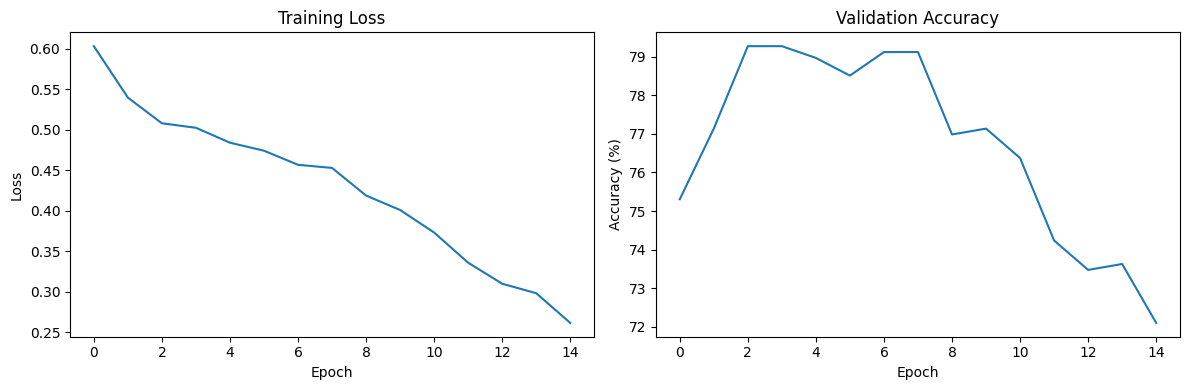

In [ ]:
# ==== STEP 2: MITOSIS CLASSIFICATION MODEL ====


# ==== STAIN AUGMENTATION FOR CLASSIFIER ====
class StainAugmentationClassifier:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if np.random.random() < self.p:
            image = np.array(image)
            # Randomly adjust H&E stain intensities
            h_factor = np.random.uniform(0.8, 1.2)
            e_factor = np.random.uniform(0.8, 1.2)
            # Modify color channels (simplified stain augmentation)
            image[:,:,0] = np.clip(image[:,:,0] * h_factor, 0, 255)  # Red channel
            image[:,:,2] = np.clip(image[:,:,2] * e_factor, 0, 255)  # Blue channel
            image = Image.fromarray(image.astype(np.uint8))
        return image

# ==== CANDIDATE EXTRACTION FROM SEGMENTATION RESULTS ====
def extract_candidates_from_segmentation(image_path, model, device, patch_size=128):
    """Extract mitotic candidates from segmentation model predictions"""
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    # Convert to tensor for model
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    # Get segmentation prediction
    model.eval()
    with torch.no_grad():
        pred_mask = model(image_tensor)
        pred_mask = torch.sigmoid(pred_mask)
        pred_mask = (pred_mask > 0.5).float()

    # Convert back to numpy
    pred_mask = pred_mask.cpu().squeeze().numpy()
    pred_mask = (pred_mask * 255).astype(np.uint8)

    # Resize mask back to original image size
    pred_mask = cv2.resize(pred_mask, original_size, interpolation=cv2.INTER_NEAREST)

    # Find connected components (candidate locations)
    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    original_image = np.array(image)

    for contour in contours:
        # Get centroid of contour
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            # Extract patch around centroid
            half_patch = patch_size // 2
            x1 = max(0, cx - half_patch)
            y1 = max(0, cy - half_patch)
            x2 = min(original_size[0], cx + half_patch)
            y2 = min(original_size[1], cy + half_patch)

            if x2 - x1 >= patch_size//2 and y2 - y1 >= patch_size//2:  # Ensure reasonable patch size
                patch = original_image[y1:y2, x1:x2]
                candidates.append({
                    'patch': patch,
                    'center': (cx, cy),
                    'bbox': (x1, y1, x2, y2)
                })

    return candidates

# ==== CLASSIFICATION DATASET ====
class MitosisClassificationDataset(Dataset):
    def __init__(self, image_dir, annotation_file, patch_size=128, transform=None):
        """
        Dataset for training mitosis vs mimicker classifier
        annotation_file should contain: image_name, x, y, label (1 for mitosis, 0 for mimicker)
        """
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.transform = transform
        self.samples = []

        # For this example, we'll create synthetic training data
        # In practice, you would load from your annotation file
        self.create_training_samples()

    def create_training_samples(self):
        """Create training samples from your annotated data"""
        print("Creating classification training samples...")

        # Get all image files
        image_files = [f for f in os.listdir(self.image_dir) if f.endswith('.png') and not f.endswith('_mask.png')]

        for img_file in tqdm(image_files):
            img_path = os.path.join(self.image_dir, img_file)
            mask_path = img_path.replace('.png', '_mask.png').replace('patches_25', 'masks_25')

            if not os.path.exists(mask_path):
                continue

            image = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))

            # Find mitotic regions (positive samples)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])

                    # Extract patch
                    half_patch = self.patch_size // 2
                    x1 = max(0, cx - half_patch)
                    y1 = max(0, cy - half_patch)
                    x2 = min(image.shape[1], cx + half_patch)
                    y2 = min(image.shape[0], cy + half_patch)

                    if x2 - x1 >= self.patch_size//2 and y2 - y1 >= self.patch_size//2:
                        patch = image[y1:y2, x1:x2]
                        self.samples.append((patch, 1))  # 1 for mitosis

            # Create negative samples (random patches from non-mitotic regions)
            mask_binary = mask > 0
            for _ in range(len(contours) * 2):  # 2x negative samples
                attempts = 0
                while attempts < 10:  # Try up to 10 times to find a good negative patch
                    cx = np.random.randint(half_patch, image.shape[1] - half_patch)
                    cy = np.random.randint(half_patch, image.shape[0] - half_patch)

                    # Check if patch overlaps with mitotic regions
                    patch_mask = mask_binary[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                    if not np.any(patch_mask):  # No overlap with mitotic regions
                        patch = image[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                        self.samples.append((patch, 0))  # 0 for non-mitosis
                        break
                    attempts += 1

        print(f"Created {len(self.samples)} training samples")
        mitosis_count = sum(1 for _, label in self.samples if label == 1)
        print(f"Mitosis samples: {mitosis_count}, Non-mitosis samples: {len(self.samples) - mitosis_count}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patch, label = self.samples[idx]

        # Resize patch to fixed size
        patch = cv2.resize(patch, (self.patch_size, self.patch_size))
        patch = Image.fromarray(patch)

        if self.transform:
            patch = self.transform(patch)

        return patch, torch.tensor(label, dtype=torch.long)

# ==== EFFICIENTNET-B7 CLASSIFIER ====
class MitosisClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(MitosisClassifier, self).__init__()
        self.backbone = efficientnet_b7(pretrained=True)
        # Replace the final classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )


    def forward(self, x):
        return self.backbone(x)

# ==== TRAINING SETUP ====
def train_classifier():
    # Configuration
    image_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/patches_25"
    patch_size = 128
    batch_size = 16
    num_epochs = 15
    learning_rate = 1e-4

    # Data transforms (including stain augmentation)
    train_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        StainAugmentationClassifier(p=0.5),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create dataset
    dataset = MitosisClassificationDataset(image_dir, None, patch_size, train_transform)

    total_size = len(dataset)
    train_val_size = int(0.85 * total_size)
    test_size = total_size - train_val_size

    train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size])

    # Now split train_val into train (90%) and val (10%)
    train_size = int(0.90 * len(train_val_dataset))
    val_size = len(train_val_dataset) - train_size

    train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MitosisClassifier(num_classes=2).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    # Training loop
    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_train_loss = 0

        print(f"Epoch {epoch+1}/{num_epochs}")
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Learning rate scheduling
        scheduler.step(avg_val_loss)

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_best.pt"
            os.makedirs(os.path.dirname(classifier_path), exist_ok=True)
            torch.save(model.state_dict(), classifier_path)
            print(f"Best model saved with validation accuracy: {best_val_acc:.2f}%")

    # Save final model
    final_classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_final.pt"
    torch.save(model.state_dict(), final_classifier_path)
    print(f"Final model saved to {final_classifier_path}")

    test_indices_path = "/content/drive/MyDrive/unet_checkpoints/test_indices_multi_to_multi.pkl"
    with open(test_indices_path, 'wb') as f:
      pickle.dump(test_dataset.indices, f)

    return model, train_losses, val_accuracies

# ==== RUN TRAINING ====
if __name__ == "__main__":
    print("Starting mitosis classifier training...")
    model, train_losses, val_accuracies = train_classifier()
    print("Training completed!")

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/unet_checkpoints/classifier_training_history.png')
    plt.show()


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from torch.utils.data import Subset
import pickle

# Load test indices
test_indices_path = "/content/drive/MyDrive/unet_checkpoints/test_indices_multi_to_multi.pkl"
with open(test_indices_path, 'rb') as f:
    test_indices = pickle.load(f)

# Rebuild the dataset and create the test_loader
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = MitosisClassificationDataset(image_dir, None, patch_size=128, transform=transform)
test_dataset = Subset(full_dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# === CONFIGURATION ===
model_cls_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_final.pt"
patch_size = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LOAD MODEL ===
from torchvision.models import efficientnet_b7
import torch.nn as nn

class MitosisClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(MitosisClassifier, self).__init__()
        self.backbone = efficientnet_b7(pretrained=True)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

classifier = MitosisClassifier(num_classes=2).to(device)
classifier.load_state_dict(torch.load(model_cls_path))
classifier.eval()

# === EVALUATE ON TEST SET ===
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# === REPORT ===
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Mitosis", "Mitosis"]))


Creating classification training samples...


100%|██████████| 10888/10888 [03:39<00:00, 49.53it/s]


Created 7718 training samples
Mitosis samples: 2564, Non-mitosis samples: 5154


Testing on Test Set: 100%|██████████| 73/73 [00:03<00:00, 22.33it/s]


Confusion Matrix:
[[623 155]
 [160 220]]

Classification Report:
              precision    recall  f1-score   support

 Non-Mitosis       0.80      0.80      0.80       778
     Mitosis       0.59      0.58      0.58       380

    accuracy                           0.73      1158
   macro avg       0.69      0.69      0.69      1158
weighted avg       0.73      0.73      0.73      1158



#Multi to Breast

Starting Multi->Breast domain adaptation training...
Training on 204 non-breast images
Testing on 150 breast images
Creating train samples for domain adaptation...
Found 5708 patches from target domain


100%|██████████| 5708/5708 [2:22:27<00:00,  1.50s/it]


Created 6335 train samples
Mitosis samples: 2105, Non-mitosis samples: 4230
Creating test samples for domain adaptation...
Found 5180 patches from target domain


100%|██████████| 5180/5180 [2:00:05<00:00,  1.39s/it]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Created 1383 test samples
Mitosis samples: 459, Non-mitosis samples: 924


...

Train Loss: 0.3015, Val Loss: 0.6027, Val Accuracy: 75.24%
Epoch 14/15


Validation: 100%|██████████| 40/40 [00:01<00:00, 22.25it/s]


Train Loss: 0.2514, Val Loss: 0.6828, Val Accuracy: 75.87%
Epoch 15/15


Validation: 100%|██████████| 40/40 [00:01<00:00, 22.18it/s]


Train Loss: 0.2270, Val Loss: 0.7909, Val Accuracy: 73.97%
Final model saved to /content/drive/MyDrive/unet_checkpoints/mitosis_classifier_multi_to_breast_final.pt
Training completed!


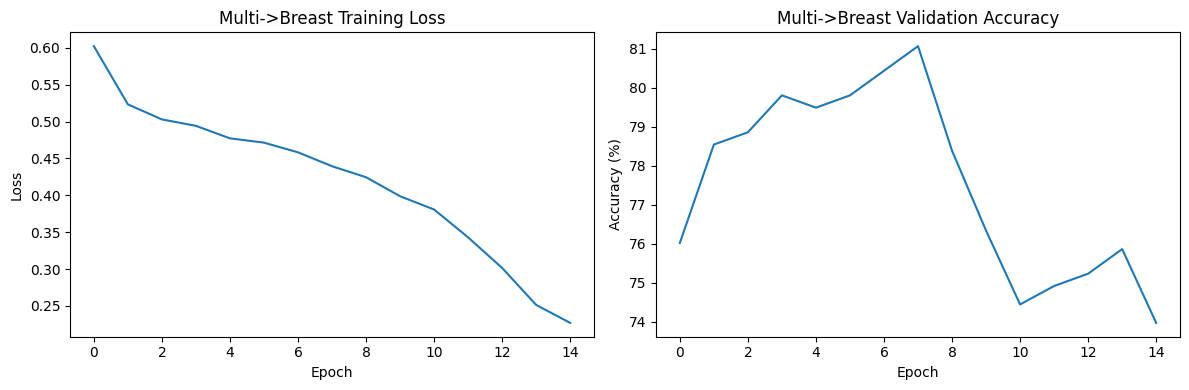


Evaluating on breast cancer test set...


Testing on Breast Cancer: 100%|██████████| 87/87 [00:03<00:00, 24.32it/s]



=== MULTI TO BREAST EVALUATION RESULTS ===
Test Accuracy on Breast Cancer: 63.85%

Confusion Matrix:
[[576 348]
 [152 307]]

Classification Report:
              precision    recall  f1-score   support

 Non-Mitosis       0.79      0.62      0.70       924
     Mitosis       0.47      0.67      0.55       459

    accuracy                           0.64      1383
   macro avg       0.63      0.65      0.62      1383
weighted avg       0.68      0.64      0.65      1383



In [ ]:
# ==== MULTI TO BREAST DOMAIN ADAPTATION ====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b7
import numpy as np
from PIL import Image
import os
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split, Subset
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import pickle
import json

# ==== CONFIGURATION FOR MULTI TO BREAST ====
def get_multi_to_breast_image_ids(coco_data):
    """
    Returns image IDs for Multi->Breast scenario:
    Train: All non-breast types (lung, lymphoma, mast_cell, neuroendocrine)
    Test: Breast carcinoma only
    """
    cancer_ranges = [
        ((1, 150), "breast"),
        ((151, 194), "lung"),
        ((195, 249), "lymphoma"),
        ((250, 299), "mast_cell"),
        ((300, 354), "neuroendocrine")
    ]

    train_ids = []  # Non-breast types
    test_ids = []   # Breast only

    for (start, end), cancer_type in cancer_ranges:
        ids = [img['id'] for img in coco_data['images'] if start <= img['id'] <= end]
        ids.sort()

        if cancer_type == "breast":
            # All breast samples go to test set
            test_ids.extend(ids)
        else:
            # All non-breast samples go to training set
            train_ids.extend(ids)

    print(f"Training on {len(train_ids)} non-breast images")
    print(f"Testing on {len(test_ids)} breast images")

    return set(train_ids), set(test_ids)

# ==== MODIFIED DATASET CLASS FOR DOMAIN SPLIT ====
class MitosisClassificationDatasetDomain(Dataset):
    def __init__(self, image_dir, annotation_file, patch_size=128, transform=None,
                 train_image_ids=None, test_image_ids=None, mode='train'):
        """
        Dataset for domain adaptation
        mode: 'train' uses train_image_ids, 'test' uses test_image_ids
        """
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.transform = transform
        self.mode = mode
        self.samples = []

        # Load COCO annotations to get domain splits
        if annotation_file:
            with open(annotation_file, 'r') as f:
                self.coco_data = json.load(f)

        # Get image IDs for the specified mode
        if mode == 'train' and train_image_ids is not None:
            self.target_image_ids = train_image_ids
        elif mode == 'test' and test_image_ids is not None:
            self.target_image_ids = test_image_ids
        else:
            raise ValueError("Must specify appropriate image_ids for the mode")

        self.create_training_samples()

    def create_training_samples(self):
        """Create training samples from domain-specific images"""
        print(f"Creating {self.mode} samples for domain adaptation...")

        # Get all image files and filter by domain
        image_files = [f for f in os.listdir(self.image_dir)
                      if f.endswith('.png') and not f.endswith('_mask.png')]

        # Filter files based on image IDs from target domain
        domain_files = []
        for img_file in image_files:
            # Extract image ID from filename (format: imageID_y_x.png)
            image_id = int(img_file.split('_')[0])
            if image_id in self.target_image_ids:
                domain_files.append(img_file)

        print(f"Found {len(domain_files)} patches from target domain")

        for img_file in tqdm(domain_files):
            img_path = os.path.join(self.image_dir, img_file)
            mask_path = img_path.replace('.png', '_mask.png').replace('patches_25', 'masks_25')

            if not os.path.exists(mask_path):
                continue

            image = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))

            # Find mitotic regions (positive samples)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])

                    # Extract patch
                    half_patch = self.patch_size // 2
                    x1 = max(0, cx - half_patch)
                    y1 = max(0, cy - half_patch)
                    x2 = min(image.shape[1], cx + half_patch)
                    y2 = min(image.shape[0], cy + half_patch)

                    if x2 - x1 >= self.patch_size//2 and y2 - y1 >= self.patch_size//2:
                        patch = image[y1:y2, x1:x2]
                        self.samples.append((patch, 1))  # 1 for mitosis

            # Create negative samples (random patches from non-mitotic regions)
            mask_binary = mask > 0
            half_patch = self.patch_size // 2

            for _ in range(len(contours) * 2):  # 2x negative samples
                attempts = 0
                while attempts < 10:
                    cx = np.random.randint(half_patch, image.shape[1] - half_patch)
                    cy = np.random.randint(half_patch, image.shape[0] - half_patch)

                    # Check if patch overlaps with mitotic regions
                    patch_mask = mask_binary[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                    if not np.any(patch_mask):  # No overlap with mitotic regions
                        patch = image[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                        self.samples.append((patch, 0))  # 0 for non-mitosis
                        break
                    attempts += 1

        print(f"Created {len(self.samples)} {self.mode} samples")
        mitosis_count = sum(1 for _, label in self.samples if label == 1)
        print(f"Mitosis samples: {mitosis_count}, Non-mitosis samples: {len(self.samples) - mitosis_count}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patch, label = self.samples[idx]

        # Resize patch to fixed size
        patch = cv2.resize(patch, (self.patch_size, self.patch_size))
        patch = Image.fromarray(patch)

        if self.transform:
            patch = self.transform(patch)

        return patch, torch.tensor(label, dtype=torch.long)

# ==== STAIN AUGMENTATION FOR CLASSIFIER ====
class StainAugmentationClassifier:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if np.random.random() < self.p:
            image = np.array(image)
            # Randomly adjust H&E stain intensities
            h_factor = np.random.uniform(0.8, 1.2)
            e_factor = np.random.uniform(0.8, 1.2)
            # Modify color channels (simplified stain augmentation)
            image[:,:,0] = np.clip(image[:,:,0] * h_factor, 0, 255)  # Red channel
            image[:,:,2] = np.clip(image[:,:,2] * e_factor, 0, 255)  # Blue channel
            image = Image.fromarray(image.astype(np.uint8))
        return image

# ==== EFFICIENTNET-B7 CLASSIFIER ====
class MitosisClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(MitosisClassifier, self).__init__()
        self.backbone = efficientnet_b7(pretrained=True)
        # Replace the final classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ==== TRAINING FUNCTION FOR MULTI TO BREAST ====
def train_multi_to_breast_classifier():
    # Configuration
    image_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/patches_25"
    annotation_json = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/MIDOG2022_training_png.json"
    patch_size = 128
    batch_size = 16
    num_epochs = 15
    learning_rate = 1e-4

    # Load COCO data and get domain splits
    with open(annotation_json, 'r') as f:
        coco_data = json.load(f)

    train_image_ids, test_image_ids = get_multi_to_breast_image_ids(coco_data)

    # Data transforms (including stain augmentation)
    train_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        StainAugmentationClassifier(p=0.5),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create domain-specific datasets
    train_dataset = MitosisClassificationDatasetDomain(
        image_dir, annotation_json, patch_size, train_transform,
        train_image_ids=train_image_ids, mode='train'
    )

    test_dataset = MitosisClassificationDatasetDomain(
        image_dir, annotation_json, patch_size, test_transform,
        test_image_ids=test_image_ids, mode='test'
    )

    # Split training data into train/val (90%/10%)
    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Data loaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MitosisClassifier(num_classes=2).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    # Training loop
    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_train_loss = 0

        print(f"Epoch {epoch+1}/{num_epochs}")
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Learning rate scheduling
        scheduler.step(avg_val_loss)

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_multi_to_breast_best.pt"
            os.makedirs(os.path.dirname(classifier_path), exist_ok=True)
            torch.save(model.state_dict(), classifier_path)
            print(f"Best model saved with validation accuracy: {best_val_acc:.2f}%")

    # Save final model
    final_classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_multi_to_breast_final.pt"
    torch.save(model.state_dict(), final_classifier_path)
    print(f"Final model saved to {final_classifier_path}")

    # Save test dataset for later evaluation
    test_indices_path = "/content/drive/MyDrive/unet_checkpoints/test_dataset_multi_to_breast.pkl"
    with open(test_indices_path, 'wb') as f:
        pickle.dump(test_dataset, f)

    return model, train_losses, val_accuracies, test_loader

# ==== EVALUATION FUNCTION ====
def evaluate_multi_to_breast():
    """Evaluate the Multi->Breast model on breast cancer test set"""

    # Configuration
    model_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_multi_to_breast_final.pt"
    test_dataset_path = "/content/drive/MyDrive/unet_checkpoints/test_dataset_multi_to_breast.pkl"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load test dataset
    with open(test_dataset_path, 'rb') as f:
        test_dataset = pickle.load(f)

    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

    # Load model
    model = MitosisClassifier(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Evaluate
    y_true, y_pred = [], []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing on Breast Cancer"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Results
    test_accuracy = 100 * correct / total
    print(f"\n=== MULTI TO BREAST EVALUATION RESULTS ===")
    print(f"Test Accuracy on Breast Cancer: {test_accuracy:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Non-Mitosis", "Mitosis"]))

    return test_accuracy, y_true, y_pred

# ==== RUN TRAINING AND EVALUATION ====
if __name__ == "__main__":
    print("Starting Multi->Breast domain adaptation training...")
    model, train_losses, val_accuracies, test_loader = train_multi_to_breast_classifier()
    print("Training completed!")

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Multi->Breast Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies)
    plt.title('Multi->Breast Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/unet_checkpoints/multi_to_breast_training_history.png')
    plt.show()

    # Evaluate on test set
    print("\nEvaluating on breast cancer test set...")
    test_accuracy, y_true, y_pred = evaluate_multi_to_breast()

#Breast to Multi

Starting Breast->Multi domain adaptation training...
Training on 150 breast images
Testing on 204 non-breast images
Creating train samples for domain adaptation...
Found 5180 patches from target domain


100%|██████████| 5180/5180 [02:08<00:00, 40.25it/s]


Created 1383 train samples
Mitosis samples: 459, Non-mitosis samples: 924
Creating test samples for domain adaptation...
Found 5708 patches from target domain


100%|██████████| 5708/5708 [02:13<00:00, 42.82it/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Created 6335 test samples
Mitosis samples: 2105, Non-mitosis samples: 4230
Epoch 1/15


...

Train Loss: 0.2365, Val Loss: 0.7850, Val Accuracy: 68.35%
Epoch 14/15


Validation: 100%|██████████| 9/9 [00:00<00:00, 14.59it/s]


Train Loss: 0.1960, Val Loss: 0.8453, Val Accuracy: 69.78%
Epoch 15/15


Validation: 100%|██████████| 9/9 [00:00<00:00, 13.57it/s]


Train Loss: 0.1784, Val Loss: 0.8014, Val Accuracy: 70.50%
Final model saved to /content/drive/MyDrive/unet_checkpoints/mitosis_classifier_breast_to_multi_final.pt
Training completed!


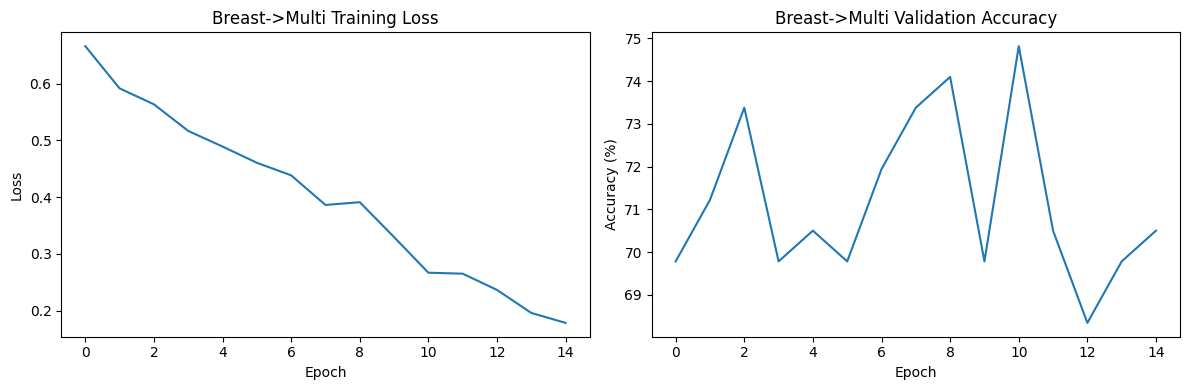


Evaluating on non-breast cancer test set...


Testing on Non-Breast Cancers: 100%|██████████| 396/396 [00:15<00:00, 25.07it/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== BREAST TO MULTI EVALUATION RESULTS ===
Test Accuracy on Non-Breast Cancers: 73.02%

Confusion Matrix:
[[3985  245]
 [1464  641]]

Classification Report:
              precision    recall  f1-score   support

 Non-Mitosis       0.73      0.94      0.82      4230
     Mitosis       0.72      0.30      0.43      2105

    accuracy                           0.73      6335
   macro avg       0.73      0.62      0.63      6335
weighted avg       0.73      0.73      0.69      6335


Detailed evaluation by cancer type...

=== Evaluating on LUNG cancer ===
Creating test samples for domain adaptation...
Found 1188 patches from target domain


100%|██████████| 1188/1188 [01:18<00:00, 15.19it/s]


Created 661 test samples
Mitosis samples: 219, Non-mitosis samples: 442


...

Mast_cell Cancer Accuracy: 73.05% (1548/2119)
Classification Report:
              precision    recall  f1-score   support

 Non-Mitosis       0.75      0.88      0.81      1416
     Mitosis       0.64      0.42      0.51       703

    accuracy                           0.73      2119
   macro avg       0.70      0.65      0.66      2119
weighted avg       0.72      0.73      0.71      2119


=== Evaluating on NEUROENDOCRINE cancer ===
Creating test samples for domain adaptation...
Found 1820 patches from target domain


100%|██████████| 1820/1820 [01:25<00:00, 21.38it/s]


Created 845 test samples
Mitosis samples: 281, Non-mitosis samples: 564


Testing neuroendocrine: 100%|██████████| 53/53 [00:02<00:00, 22.08it/s]


Neuroendocrine Cancer Accuracy: 69.59% (588/845)
Classification Report:
              precision    recall  f1-score   support

 Non-Mitosis       0.75      0.83      0.78       564
     Mitosis       0.55      0.43      0.49       281

    accuracy                           0.70       845
   macro avg       0.65      0.63      0.64       845
weighted avg       0.68      0.70      0.69       845


=== BREAST TO MULTI - SUMMARY BY CANCER TYPE ===
Lung: 75.95% (661 samples)
Lymphoma: 72.40% (2710 samples)
Mast_cell: 73.05% (2119 samples)
Neuroendocrine: 69.59% (845 samples)


In [ ]:
# ==== BREAST TO MULTI DOMAIN ADAPTATION ====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b7
import numpy as np
from PIL import Image
import os
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split, Subset
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import pickle
import json

# ==== CONFIGURATION FOR BREAST TO MULTI ====
def get_breast_to_multi_image_ids(coco_data):
    """
    Returns image IDs for Breast->Multi scenario:
    Train: Breast carcinoma only
    Test: All non-breast types (lung, lymphoma, mast_cell, neuroendocrine)
    """
    cancer_ranges = [
        ((1, 150), "breast"),
        ((151, 194), "lung"),
        ((195, 249), "lymphoma"),
        ((250, 299), "mast_cell"),
        ((300, 354), "neuroendocrine")
    ]

    train_ids = []  # Breast only
    test_ids = []   # Non-breast types

    for (start, end), cancer_type in cancer_ranges:
        ids = [img['id'] for img in coco_data['images'] if start <= img['id'] <= end]
        ids.sort()

        if cancer_type == "breast":
            # All breast samples go to training set
            train_ids.extend(ids)
        else:
            # All non-breast samples go to test set
            test_ids.extend(ids)

    print(f"Training on {len(train_ids)} breast images")
    print(f"Testing on {len(test_ids)} non-breast images")

    return set(train_ids), set(test_ids)

# ==== MODIFIED DATASET CLASS FOR DOMAIN SPLIT ====
class MitosisClassificationDatasetDomain(Dataset):
    def __init__(self, image_dir, annotation_file, patch_size=128, transform=None,
                 train_image_ids=None, test_image_ids=None, mode='train'):
        """
        Dataset for domain adaptation
        mode: 'train' uses train_image_ids, 'test' uses test_image_ids
        """
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.transform = transform
        self.mode = mode
        self.samples = []

        # Load COCO annotations to get domain splits
        if annotation_file:
            with open(annotation_file, 'r') as f:
                self.coco_data = json.load(f)

        # Get image IDs for the specified mode
        if mode == 'train' and train_image_ids is not None:
            self.target_image_ids = train_image_ids
        elif mode == 'test' and test_image_ids is not None:
            self.target_image_ids = test_image_ids
        else:
            raise ValueError("Must specify appropriate image_ids for the mode")

        self.create_training_samples()

    def create_training_samples(self):
        """Create training samples from domain-specific images"""
        print(f"Creating {self.mode} samples for domain adaptation...")

        # Get all image files and filter by domain
        image_files = [f for f in os.listdir(self.image_dir)
                      if f.endswith('.png') and not f.endswith('_mask.png')]

        # Filter files based on image IDs from target domain
        domain_files = []
        for img_file in image_files:
            # Extract image ID from filename (format: imageID_y_x.png)
            image_id = int(img_file.split('_')[0])
            if image_id in self.target_image_ids:
                domain_files.append(img_file)

        print(f"Found {len(domain_files)} patches from target domain")

        for img_file in tqdm(domain_files):
            img_path = os.path.join(self.image_dir, img_file)
            mask_path = img_path.replace('.png', '_mask.png').replace('patches_25', 'masks_25')

            if not os.path.exists(mask_path):
                continue

            image = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))

            # Find mitotic regions (positive samples)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                M = cv2.moments(contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])

                    # Extract patch
                    half_patch = self.patch_size // 2
                    x1 = max(0, cx - half_patch)
                    y1 = max(0, cy - half_patch)
                    x2 = min(image.shape[1], cx + half_patch)
                    y2 = min(image.shape[0], cy + half_patch)

                    if x2 - x1 >= self.patch_size//2 and y2 - y1 >= self.patch_size//2:
                        patch = image[y1:y2, x1:x2]
                        self.samples.append((patch, 1))  # 1 for mitosis

            # Create negative samples (random patches from non-mitotic regions)
            mask_binary = mask > 0
            half_patch = self.patch_size // 2

            for _ in range(len(contours) * 2):  # 2x negative samples
                attempts = 0
                while attempts < 10:
                    cx = np.random.randint(half_patch, image.shape[1] - half_patch)
                    cy = np.random.randint(half_patch, image.shape[0] - half_patch)

                    # Check if patch overlaps with mitotic regions
                    patch_mask = mask_binary[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                    if not np.any(patch_mask):  # No overlap with mitotic regions
                        patch = image[cy-half_patch:cy+half_patch, cx-half_patch:cx+half_patch]
                        self.samples.append((patch, 0))  # 0 for non-mitosis
                        break
                    attempts += 1

        print(f"Created {len(self.samples)} {self.mode} samples")
        mitosis_count = sum(1 for _, label in self.samples if label == 1)
        print(f"Mitosis samples: {mitosis_count}, Non-mitosis samples: {len(self.samples) - mitosis_count}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patch, label = self.samples[idx]

        # Resize patch to fixed size
        patch = cv2.resize(patch, (self.patch_size, self.patch_size))
        patch = Image.fromarray(patch)

        if self.transform:
            patch = self.transform(patch)

        return patch, torch.tensor(label, dtype=torch.long)

# ==== STAIN AUGMENTATION FOR CLASSIFIER ====
class StainAugmentationClassifier:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if np.random.random() < self.p:
            image = np.array(image)
            # Randomly adjust H&E stain intensities
            h_factor = np.random.uniform(0.8, 1.2)
            e_factor = np.random.uniform(0.8, 1.2)
            # Modify color channels (simplified stain augmentation)
            image[:,:,0] = np.clip(image[:,:,0] * h_factor, 0, 255)  # Red channel
            image[:,:,2] = np.clip(image[:,:,2] * e_factor, 0, 255)  # Blue channel
            image = Image.fromarray(image.astype(np.uint8))
        return image

# ==== EFFICIENTNET-B7 CLASSIFIER ====
class MitosisClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(MitosisClassifier, self).__init__()
        self.backbone = efficientnet_b7(pretrained=True)
        # Replace the final classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ==== TRAINING FUNCTION FOR BREAST TO MULTI ====
def train_breast_to_multi_classifier():
    # Configuration
    image_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/patches_25"
    annotation_json = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/MIDOG2022_training_png.json"
    patch_size = 128
    batch_size = 16
    num_epochs = 15
    learning_rate = 1e-4

    # Load COCO data and get domain splits
    with open(annotation_json, 'r') as f:
        coco_data = json.load(f)

    train_image_ids, test_image_ids = get_breast_to_multi_image_ids(coco_data)

    # Data transforms (including stain augmentation)
    train_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        StainAugmentationClassifier(p=0.5),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create domain-specific datasets
    train_dataset = MitosisClassificationDatasetDomain(
        image_dir, annotation_json, patch_size, train_transform,
        train_image_ids=train_image_ids, mode='train'
    )

    test_dataset = MitosisClassificationDatasetDomain(
        image_dir, annotation_json, patch_size, test_transform,
        test_image_ids=test_image_ids, mode='test'
    )

    # Split training data into train/val (90%/10%)
    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Data loaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MitosisClassifier(num_classes=2).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    # Training loop
    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_train_loss = 0

        print(f"Epoch {epoch+1}/{num_epochs}")
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Learning rate scheduling
        scheduler.step(avg_val_loss)

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_breast_to_multi_best.pt"
            os.makedirs(os.path.dirname(classifier_path), exist_ok=True)
            torch.save(model.state_dict(), classifier_path)
            print(f"Best model saved with validation accuracy: {best_val_acc:.2f}%")

    # Save final model
    final_classifier_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_breast_to_multi_final.pt"
    torch.save(model.state_dict(), final_classifier_path)
    print(f"Final model saved to {final_classifier_path}")

    # Save test dataset for later evaluation
    test_indices_path = "/content/drive/MyDrive/unet_checkpoints/test_dataset_breast_to_multi.pkl"
    with open(test_indices_path, 'wb') as f:
        pickle.dump(test_dataset, f)

    return model, train_losses, val_accuracies, test_loader

# ==== EVALUATION FUNCTION ====
def evaluate_breast_to_multi():
    """Evaluate the Breast->Multi model on non-breast cancer test set"""

    # Configuration
    model_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_breast_to_multi_final.pt"
    test_dataset_path = "/content/drive/MyDrive/unet_checkpoints/test_dataset_breast_to_multi.pkl"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load test dataset
    with open(test_dataset_path, 'rb') as f:
        test_dataset = pickle.load(f)

    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

    # Load model
    model = MitosisClassifier(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Evaluate
    y_true, y_pred = [], []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing on Non-Breast Cancers"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Results
    test_accuracy = 100 * correct / total
    print(f"\n=== BREAST TO MULTI EVALUATION RESULTS ===")
    print(f"Test Accuracy on Non-Breast Cancers: {test_accuracy:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Non-Mitosis", "Mitosis"]))

    return test_accuracy, y_true, y_pred

# ==== DETAILED EVALUATION BY CANCER TYPE ====
def evaluate_breast_to_multi_by_type():
    """Evaluate the Breast->Multi model separately for each non-breast cancer type"""

    # Configuration
    model_path = "/content/drive/MyDrive/unet_checkpoints/mitosis_classifier_breast_to_multi_final.pt"
    image_dir = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/patches_25"
    annotation_json = "/content/drive/MyDrive/MIDOG_Challenge_2022_png/MIDOG2022_training_png.json"
    patch_size = 128
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model
    model = MitosisClassifier(num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Test transform
    test_transform = transforms.Compose([
        transforms.Resize((patch_size, patch_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load COCO data
    with open(annotation_json, 'r') as f:
        coco_data = json.load(f)

    # Define cancer types and their ranges (excluding breast)
    cancer_types = [
        ((151, 194), "lung"),
        ((195, 249), "lymphoma"),
        ((250, 299), "mast_cell"),
        ((300, 354), "neuroendocrine")
    ]

    results = {}

    for (start, end), cancer_type in cancer_types:
        print(f"\n=== Evaluating on {cancer_type.upper()} cancer ===")

        # Get image IDs for this cancer type
        cancer_image_ids = set([img['id'] for img in coco_data['images'] if start <= img['id'] <= end])

        # Create dataset for this cancer type
        cancer_dataset = MitosisClassificationDatasetDomain(
            image_dir, annotation_json, patch_size, test_transform,
            test_image_ids=cancer_image_ids, mode='test'
        )

        if len(cancer_dataset) == 0:
            print(f"No samples found for {cancer_type}")
            continue

        cancer_loader = DataLoader(cancer_dataset, batch_size=16, shuffle=False, num_workers=2)

        # Evaluate on this cancer type
        y_true, y_pred = [], []
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(cancer_loader, desc=f"Testing {cancer_type}"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        # Calculate results for this cancer type
        accuracy = 100 * correct / total
        results[cancer_type] = {
            'accuracy': accuracy,
            'total_samples': total,
            'y_true': y_true,
            'y_pred': y_pred
        }

        print(f"{cancer_type.capitalize()} Cancer Accuracy: {accuracy:.2f}% ({correct}/{total})")
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=["Non-Mitosis", "Mitosis"]))

    # Overall summary
    print(f"\n=== BREAST TO MULTI - SUMMARY BY CANCER TYPE ===")
    for cancer_type, result in results.items():
        print(f"{cancer_type.capitalize()}: {result['accuracy']:.2f}% ({result['total_samples']} samples)")

    return results

# ==== RUN TRAINING AND EVALUATION ====
if __name__ == "__main__":
    print("Starting Breast->Multi domain adaptation training...")
    model, train_losses, val_accuracies, test_loader = train_breast_to_multi_classifier()
    print("Training completed!")
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Breast->Multi Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies)
    plt.title('Breast->Multi Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/unet_checkpoints/breast_to_multi_training_history.png')
    plt.show()

    # Evaluate on test set
    print("\nEvaluating on non-breast cancer test set...")
    test_accuracy, y_true, y_pred = evaluate_breast_to_multi()

    # Detailed evaluation by cancer type
    print("\nDetailed evaluation by cancer type...")
    detailed_results = evaluate_breast_to_multi_by_type()

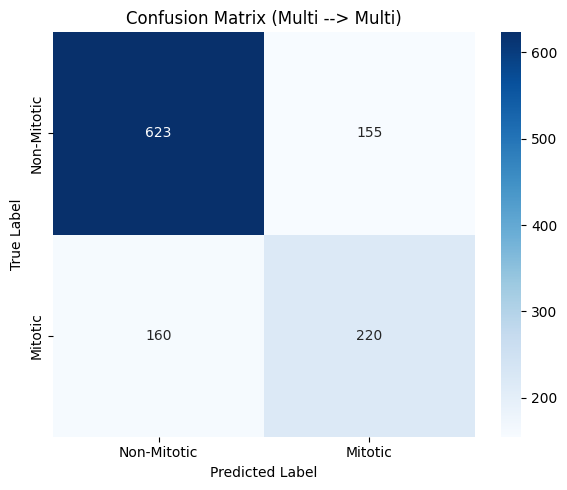

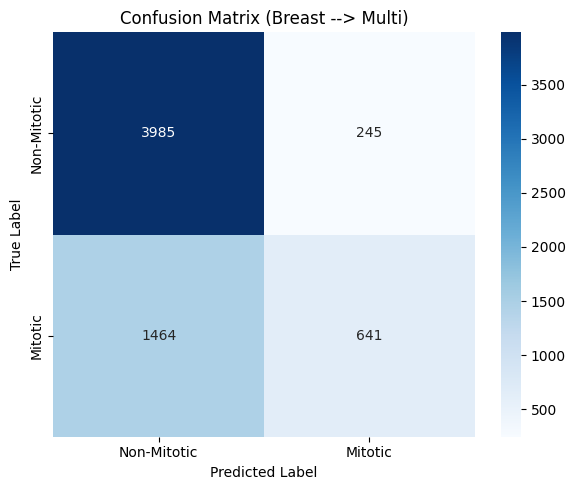

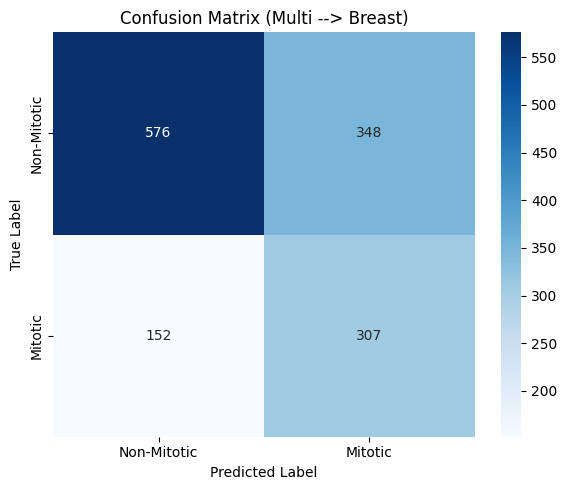

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of confusion matrices and their titles
conf_matrices = [
    (np.array([[623, 155], [160, 220]]), 'Confusion Matrix (Multi --> Multi)'),
    (np.array([[3985, 245], [1464, 641]]), 'Confusion Matrix (Breast --> Multi)'),
    (np.array([[576, 348], [152, 307]]), 'Confusion Matrix (Multi --> Breast)')
]

labels = ['Non-Mitotic', 'Mitotic']

# Plot all confusion matrices
for cm, title in conf_matrices:
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()
